In [2]:
import os
import gc
import random
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

cwd = os.getcwd()
project_candidate = os.path.abspath(os.path.join(cwd, ".."))
if os.path.exists(os.path.join(project_candidate, "dataset")):
    PROJECT_ROOT = project_candidate
else:
    PROJECT_ROOT = cwd

DATASET_DIR = os.path.join(PROJECT_ROOT, "dataset")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
DATASET_PATH = os.path.join(DATASET_DIR, "realwaste", "realwaste-main", "RealWaste")

os.makedirs(RESULTS_DIR, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("TensorFlow:", tf.__version__)
print("Dataset expected at:", DATASET_PATH)


Project root: c:\Users\Thivvi\Desktop\Deep learning repeat\EfficientNetB0
TensorFlow: 2.21.0
Dataset expected at: c:\Users\Thivvi\Desktop\Deep learning repeat\EfficientNetB0\dataset\realwaste\realwaste-main\RealWaste


In [3]:
import urllib.request

ZIP_PATH = os.path.join(DATASET_DIR, "realwaste.zip")
EXTRACT_DIR = os.path.join(DATASET_DIR, "realwaste")

if not os.path.exists(DATASET_PATH):
    if not os.path.exists(ZIP_PATH):
        print("Downloading RealWaste dataset...")
        urllib.request.urlretrieve("https://archive.ics.uci.edu/static/public/908/realwaste.zip", ZIP_PATH)
    print("Extracting RealWaste dataset...")
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)

print("Dataset available:", os.path.exists(DATASET_PATH))
print("Extracted dataset path:", DATASET_PATH)


Extracting RealWaste dataset...
Dataset available: True
Extracted dataset path: c:\Users\Thivvi\Desktop\Deep learning repeat\EfficientNetB0\dataset\realwaste\realwaste-main\RealWaste


In [4]:
print("Local dataset is already available in the project folder; no upload required.")


Local dataset is already available in the project folder; no upload required.


In [5]:
train_df = pd.read_csv(os.path.join(DATASET_DIR, "splits", "train.csv"))
val_df = pd.read_csv(os.path.join(DATASET_DIR, "splits", "validation.csv"))
test_df = pd.read_csv(os.path.join(DATASET_DIR, "splits", "test.csv"))

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 3326
Validation: 713
Test: 713


In [6]:
class_names = sorted(train_df["label"].unique())
NUM_CLASSES = len(class_names)

class_to_index = {name: index for index, name in enumerate(class_names)}

def prepare_dataframe(df):
    df = df.copy()
    df["filepath"] = df["relative_path"].apply(lambda x: os.path.join(DATASET_PATH, x))
    df["label_index"] = df["label"].map(class_to_index)
    return df

train_df = prepare_dataframe(train_df)
val_df = prepare_dataframe(val_df)
test_df = prepare_dataframe(test_df)

print(class_names)
print("Classes:", NUM_CLASSES)


['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Classes: 9


In [7]:
def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    return image, label

def create_dataset(df, training=False):
    ds = tf.data.Dataset.from_tensor_slices((df["filepath"].values, df["label_index"].values))
    if training:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(train_df, training=True)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)

print("Datasets ready")


Datasets ready


In [8]:
def get_augmentation():
    return tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomZoom(0.1)
    ])

In [9]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6
    )
]

In [10]:
tf.keras.backend.clear_session()
gc.collect()

efficient_base = tf.keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

efficient_base.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = get_augmentation()(inputs)
x = efficient_base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

efficient_model = tf.keras.Model(inputs, outputs)

efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

efficient_model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,061,100 (15.49 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [11]:
efficient_history = efficient_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15


c:\Users\Thivvi\Desktop\Deep learning repeat\EfficientNetB0\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


104/104 ━━━━━━━━━━━━━━━━━━━━ 80s 603ms/step - accuracy: 0.5520 - loss: 1.3111 - val_accuracy: 0.7195 - val_loss: 0.8496 - learning_rate: 0.0010
Epoch 2/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 63s 610ms/step - accuracy: 0.7333 - loss: 0.8060 - val_accuracy: 0.7616 - val_loss: 0.6997 - learning_rate: 0.0010
Epoch 3/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 80s 768ms/step - accuracy: 0.7739 - loss: 0.6852 - val_accuracy: 0.7910 - val_loss: 0.6276 - learning_rate: 0.0010
Epoch 4/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 81s 782ms/step - accuracy: 0.8013 - loss: 0.6019 - val_accuracy: 0.7924 - val_loss: 0.5884 - learning_rate: 0.0010
Epoch 5/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 81s 776ms/step - accuracy: 0.8142 - loss: 0.5539 - val_accuracy: 0.7966 - val_loss: 0.5711 - learning_rate: 0.0010
Epoch 6/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 83s 799ms/step - accuracy: 0.8310 - loss: 0.5186 - val_accuracy: 0.8093 - val_loss: 0.5403 - learning_rate: 0.0010
Epoch 7/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 79s 760ms/step - accuracy: 0.8416 - loss:

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(efficient_history.history["accuracy"], label="Training Accuracy")
plt.plot(efficient_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetB0 Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "EfficientNetB0_accuracy.png"), dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(efficient_history.history["loss"], label="Training Loss")
plt.plot(efficient_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB0 Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "EfficientNetB0_loss.png"), dpi=300, bbox_inches="tight")
plt.show()


In [12]:
efficient_base.trainable = True

for layer in efficient_base.layers[:-30]:
    layer.trainable = False

for layer in efficient_base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

efficient_fine_history = efficient_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=callbacks
)

Epoch 1/8
104/104 ━━━━━━━━━━━━━━━━━━━━ 120s 928ms/step - accuracy: 0.8794 - loss: 0.3602 - val_accuracy: 0.8289 - val_loss: 0.4624 - learning_rate: 1.0000e-05
Epoch 2/8
104/104 ━━━━━━━━━━━━━━━━━━━━ 4477s 43s/step - accuracy: 0.8903 - loss: 0.3359 - val_accuracy: 0.8415 - val_loss: 0.4553 - learning_rate: 1.0000e-05
Epoch 3/8
104/104 ━━━━━━━━━━━━━━━━━━━━ 52s 500ms/step - accuracy: 0.8773 - loss: 0.3521 - val_accuracy: 0.8345 - val_loss: 0.4499 - learning_rate: 1.0000e-05
Epoch 4/8
104/104 ━━━━━━━━━━━━━━━━━━━━ 120s 865ms/step - accuracy: 0.8879 - loss: 0.3315 - val_accuracy: 0.8373 - val_loss: 0.4498 - learning_rate: 1.0000e-05
Epoch 5/8
104/104 ━━━━━━━━━━━━━━━━━━━━ 89s 859ms/step - accuracy: 0.8948 - loss: 0.3120 - val_accuracy: 0.8373 - val_loss: 0.4433 - learning_rate: 1.0000e-05
Epoch 6/8
104/104 ━━━━━━━━━━━━━━━━━━━━ 142s 857ms/step - accuracy: 0.8885 - loss: 0.3156 - val_accuracy: 0.8359 - val_loss: 0.4413 - learning_rate: 1.0000e-05
Epoch 7/8
104/104 ━━━━━━━━━━━━━━━━━━━━ 89s 860ms/

In [13]:
def evaluate_model(model, model_name):
    test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

    y_true = []
    y_pred = []

    for images, labels in test_ds:
        predictions = model.predict(images, verbose=0)
        predictions = np.argmax(predictions, axis=1)
        y_true.extend(labels.numpy())
        y_pred.extend(predictions)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(model_name, "Test Results")
    print("Accuracy :", f"{accuracy:.4f}")
    print("Precision:", f"{precision:.4f}")
    print("Recall   :", f"{recall:.4f}")
    print("F1 Score :", f"{f1:.4f}")

    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    pd.DataFrame(report).transpose().to_csv(
        os.path.join(RESULTS_DIR, f"{model_name}_classification_report.csv")
    )

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    fig, ax = plt.subplots(figsize=(11, 10))
    disp.plot(ax=ax, xticks_rotation=45, values_format="d")
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.savefig(
        os.path.join(RESULTS_DIR, f"{model_name}_confusion_matrix.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    results_df = pd.DataFrame([{
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Test Loss": test_loss
    }])

    results_df.to_csv(
        os.path.join(RESULTS_DIR, f"{model_name}_results.csv"),
        index=False
    )

    return results_df


23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 382ms/step - accuracy: 0.8626 - loss: 0.4131
EfficientNetB0 Test Results
Accuracy : 0.8626
Precision: 0.8636
Recall   : 0.8626
F1 Score : 0.8615


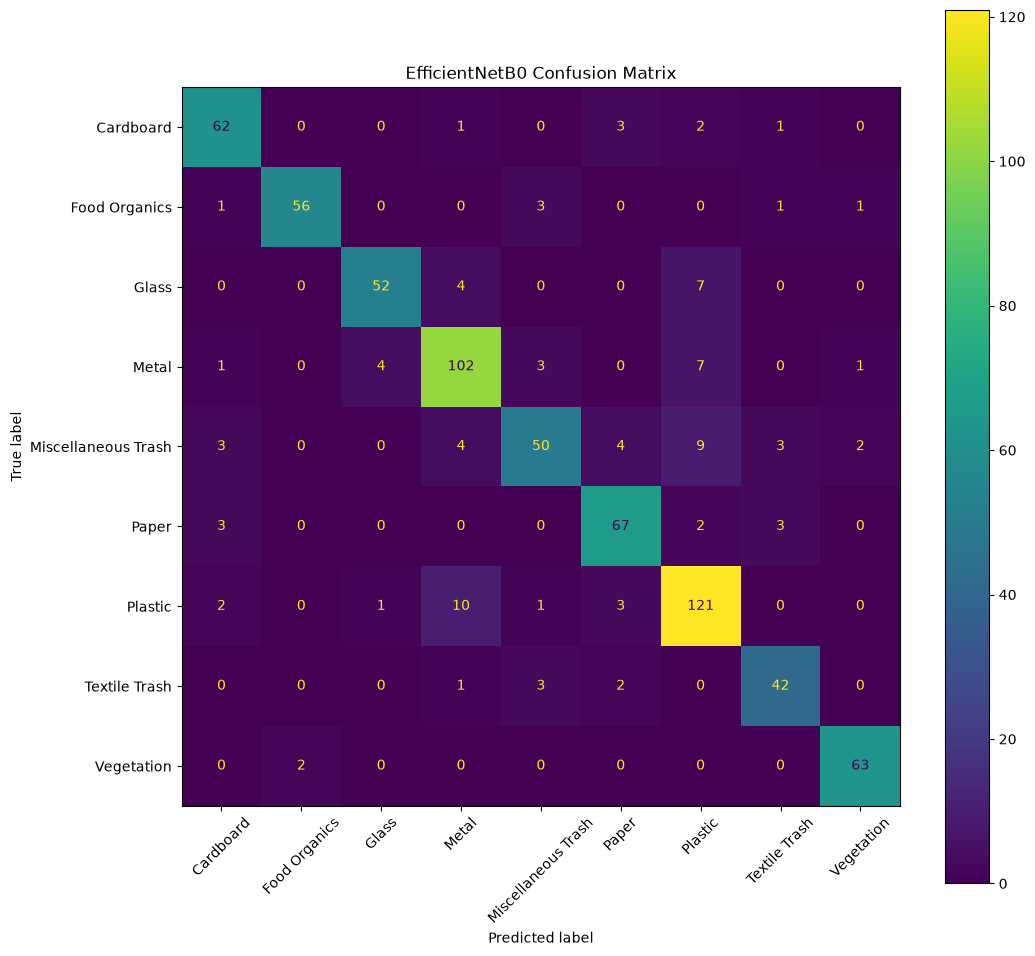

Saved model: c:\Users\Thivvi\Desktop\Deep learning repeat\EfficientNetB0\results\EfficientNetB0.keras


,Model,Accuracy,Precision,Recall,F1 Score,Test Loss
0,EfficientNetB0,0.862553,0.863646,0.862553,0.861459,0.413085


In [14]:
efficient_results = evaluate_model(efficient_model, "EfficientNetB0")
model_path = os.path.join(RESULTS_DIR, "EfficientNetB0.keras")
efficient_model.save(model_path)
print("Saved model:", model_path)
efficient_results


In [15]:
import shutil

archive_path = os.path.join(PROJECT_ROOT, "EfficientNetB0_results.zip")
if os.path.exists(archive_path):
    os.remove(archive_path)

shutil.make_archive(
    os.path.join(PROJECT_ROOT, "EfficientNetB0_results"),
    "zip",
    RESULTS_DIR
)

print("Archive created:", archive_path)


Archive created: c:\Users\Thivvi\Desktop\Deep learning repeat\EfficientNetB0\EfficientNetB0_results.zip
